# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

In [79]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "gpt-4.1-mini"
# openai = OpenAI()
openai = OpenAI(base_url="https://api.openai.com/v1", api_key=openai_api_key)
# ollama_base_url = os.getenv('OLLAMA_BASE_URL')
# MODEL = os.getenv('OLLAMA_MODEL')
# MODEL1 = os.getenv('GEMMA_MODEL')

# openai = OpenAI(api_key='ollama', base_url=ollama_base_url)

DB = "prices.db"

OpenAI API Key exists and begins sk-proj-


In [80]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [81]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [82]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [83]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [ ]:

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

DEBUG:httpcore.connection:connect_tcp.started host='api.gradio.app' port=443 local_address=None timeout=3 socket_options=None
DEBUG:httpcore.connection:connect_tcp.started host='127.0.0.1' port=7891 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x153da83b0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'date', b'Wed, 03 Jun 2026 04:15:29 GMT'), (b'server', b'uvicorn'), (b'content-length', b'4'), (b'content-type', b'application/json')])
INFO:httpx:HTTP Request: GET http://127.0.0.1:7891/gradio_ap

* Running on local URL:  http://127.0.0.1:7891
* To create a public link, set `share=True` in `launch()`.


DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): huggingface.co:443


DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics HTTP/1.1" 200 0
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x1297147d0>
DEBUG:httpcore.connection:start_tls.started ssl_context=<ssl.SSLContext object at 0x1298fe350> server_hostname='api.gradio.app' timeout=3
DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry HTTP/1.1" 200 0
DEBUG:httpcore.connection:start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x1297143b0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEB

In [86]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [87]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

DEBUG:httpcore.connection:connect_tcp.started host='api.gradio.app' port=443 local_address=None timeout=3 socket_options=None
DEBUG:httpcore.connection:connect_tcp.started host='127.0.0.1' port=7892 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x129838710>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'date', b'Wed, 03 Jun 2026 04:18:30 GMT'), (b'server', b'uvicorn'), (b'content-length', b'4'), (b'content-type', b'application/json')])
INFO:httpx:HTTP Request: GET http://127.0.0.1:7892/gradio_ap

* Running on local URL:  http://127.0.0.1:7892
* To create a public link, set `share=True` in `launch()`.


DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): huggingface.co:443


DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x1546aaab0>
DEBUG:httpcore.connection:start_tls.started ssl_context=<ssl.SSLContext object at 0x12884f250> server_hostname='api.gradio.app' timeout=3
DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics HTTP/1.1" 200 0
DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry HTTP/1.1" 200 0
DEBUG:httpcore.connection:start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x15394c290>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEB

DATABASE TOOL CALLED: Getting price for Tokyo


DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/chat/completions', 'files': None, 'idempotency_key': 'stainless-python-retry-428e6e20-960a-4420-9a2e-e3a94cb4f201', 'json_data': {'messages': [{'role': 'system', 'content': "\nYou are a helpful assistant for an Airline called FlightAI.\nGive short, courteous answers, no more than 1 sentence.\nAlways be accurate. If you don't know the answer, say so.\n"}, {'role': 'user', 'content': 'Hi'}, {'role': 'assistant', 'content': 'Hello! How can I assist you with your flight today?'}, {'role': 'user', 'content': 'Could you please check some tickets to Tokyo ?'}, {'content': None, 'refusal': None, 'role': 'assistant', 'annotations': [], 'tool_calls': [{'id': 'call_GeUSLOiZOA0bWmcp7ZkVp4nQ', 'function': {'arguments': '{"destination_city":"Tokyo"}', 'name': 'get_ticket_price'}, 'type': 'function'}]}, {'role': 'tool', 'content': 'Ticket price to Tokyo is $1420.0', 'tool_call_id': 'call_GeUSLOiZOA0bWmcp7ZkVp4nQ'}], 'model': 'gpt-

DATABASE TOOL CALLED: Getting price for London


DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/chat/completions', 'files': None, 'idempotency_key': 'stainless-python-retry-0130ea73-60cb-45ea-9ed2-00ba49440673', 'json_data': {'messages': [{'role': 'system', 'content': "\nYou are a helpful assistant for an Airline called FlightAI.\nGive short, courteous answers, no more than 1 sentence.\nAlways be accurate. If you don't know the answer, say so.\n"}, {'role': 'user', 'content': 'Hi'}, {'role': 'assistant', 'content': 'Hello! How can I assist you with your flight today?'}, {'role': 'user', 'content': 'Could you please check some tickets to Tokyo ?'}, {'role': 'assistant', 'content': 'The price of a return ticket to Tokyo is $1420.'}, {'role': 'user', 'content': 'we have 4 members, go on a trip Tokyo in 4 days'}, {'role': 'assistant', 'content': 'For 4 members, the total cost for return tickets to Tokyo in 4 days will be $5680.'}, {'role': 'user', 'content': 'too expensive'}, {'role': 'assistant', 'content': 'I un

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [89]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [90]:
print("base_url:", openai.base_url)
print("api_key prefix:", str(openai.api_key)[:10])
import os
print("OPENAI_BASE_URL env:", os.getenv("OPENAI_BASE_URL"))
print("OPENAI_API_BASE env:", os.getenv("OPENAI_API_BASE"))
print("OPENAI_PROJECT env:", os.getenv("OPENAI_PROJECT"))
print("OPENAI_ORG env:", os.getenv("OPENAI_ORG_ID") or os.getenv("OPENAI_ORGANIZATION"))


base_url: https://api.openai.com/v1/
api_key prefix: sk-proj-kv
OPENAI_BASE_URL env: None
OPENAI_API_BASE env: None
OPENAI_PROJECT env: None
OPENAI_ORG env: None


In [91]:
def artist(city):
    image_response = openai.images.generate(
            model="gpt-image-1-mini",
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))


DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/images/generations', 'files': None, 'idempotency_key': 'stainless-python-retry-bc715ab2-98d0-4788-8755-c390a7ab8513', 'json_data': {'prompt': 'An image representing a vacation in Tokyo, showing tourist spots and everything unique about Tokyo, in a vibrant pop-art style', 'model': 'gpt-image-1-mini', 'n': 1, 'size': '1024x1024'}}
DEBUG:openai._base_client:Sending HTTP Request: POST https://api.openai.com/v1/images/generations
DEBUG:httpcore.connection:close.started
DEBUG:httpcore.connection:close.complete
DEBUG:httpcore.connection:connect_tcp.started host='api.openai.com' port=443 local_address=None timeout=5.0 socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x13224a7b0>
DEBUG:httpcore.connection:start_tls.started ssl_context=<ssl.SSLContext object at 0x128827350> server_hostname='api.openai.com' timeout=5.0
DEBUG:httpcore.connection:start_

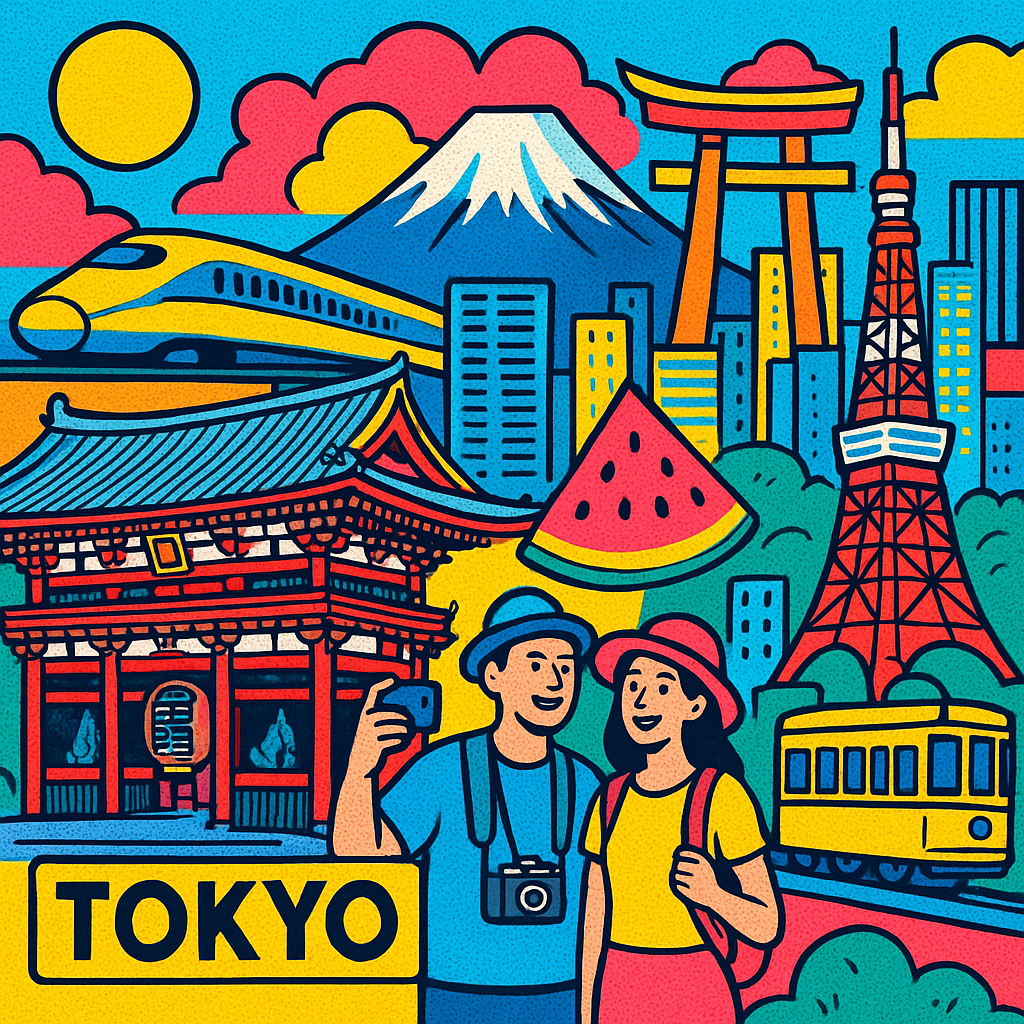

In [92]:
image = artist("Tokyo")
display(image)

In [94]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [95]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [96]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [ ]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("ed", "bananas"))

DEBUG:httpcore.connection:connect_tcp.started host='api.gradio.app' port=443 local_address=None timeout=3 socket_options=None
DEBUG:urllib3.connectionpool:Resetting dropped connection: huggingface.co
DEBUG:httpcore.connection:connect_tcp.started host='127.0.0.1' port=7893 local_address=None timeout=None socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x12a596540>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'date', b'Wed, 03 Jun 2026 04:26:53 GMT'), (b'server', b'uvicorn'), (b'content-length', b'4'), (b'content-type', b'applica

* Running on local URL:  http://127.0.0.1:7893
* To create a public link, set `share=True` in `launch()`.


DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics HTTP/1.1" 200 0


DEBUG:urllib3.connectionpool:https://huggingface.co:443 "HEAD /api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry HTTP/1.1" 200 0
DEBUG:httpcore.connection:start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x1286188c0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 200, b'OK', [(b'Date', b'Wed, 03 Jun 2026 04:26:54 GMT'), (b'Content-Type', b'application/json'), (b'Content-Length', b'21'), (b'Connection', b'keep-alive'), (b'Server', b'nginx/1.18.0'), (b'Access-Control-Allow-Origin', b'*')])
INFO:httpx:HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
DEBUG:http

DATABASE TOOL CALLED: Getting price for Tokyo


DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/chat/completions', 'files': None, 'idempotency_key': 'stainless-python-retry-e872b280-1a2d-4fbc-94bc-4dca1902a9cb', 'json_data': {'messages': [{'role': 'system', 'content': "\nYou are a helpful assistant for an Airline called FlightAI.\nGive short, courteous answers, no more than 1 sentence.\nAlways be accurate. If you don't know the answer, say so.\n"}, {'role': 'user', 'content': 'hi'}, {'role': 'assistant', 'content': 'Hello! How can I assist you with your flight today?'}, {'role': 'user', 'content': 'I want to go on a trip Tokyo'}, {'role': 'assistant', 'content': 'May I know if you need a one-way or a return ticket to Tokyo?'}, {'role': 'user', 'content': 'one way, could you please let me know what price of the ticket ? We have 4 members, go in 4 days and want to see some picture of Tokyo'}, {'content': None, 'refusal': None, 'role': 'assistant', 'annotations': [], 'tool_calls': [{'id': 'call_YWZ1AlqAyjryD4IWmw

DATABASE TOOL CALLED: Getting price for Hanoi


DEBUG:openai._base_client:Request options: {'method': 'post', 'url': '/chat/completions', 'files': None, 'idempotency_key': 'stainless-python-retry-f25e76d9-3a89-45eb-9d79-30569e94cc61', 'json_data': {'messages': [{'role': 'system', 'content': "\nYou are a helpful assistant for an Airline called FlightAI.\nGive short, courteous answers, no more than 1 sentence.\nAlways be accurate. If you don't know the answer, say so.\n"}, {'role': 'user', 'content': 'hi'}, {'role': 'assistant', 'content': 'Hello! How can I assist you with your flight today?'}, {'role': 'user', 'content': 'I want to go on a trip Tokyo'}, {'role': 'assistant', 'content': 'May I know if you need a one-way or a return ticket to Tokyo?'}, {'role': 'user', 'content': 'one way, could you please let me know what price of the ticket ? We have 4 members, go in 4 days and want to see some picture of Tokyo'}, {'role': 'assistant', 'content': 'The price for a one-way ticket to Tokyo is $1420 per person; for 4 members, it will be 

# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>